# Flower_Classification

In [1]:
import zipfile
import os
import json
import torch
from torchvision import datasets, transforms
from torch.utils.data import Dataset
from PIL import Image
import torch.nn as nn
from torchvision import models
import torch.optim as optim
from torch.optim import lr_scheduler
import copy
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
!ls "/content/drive/MyDrive/Flower Classification/data/dataset"

test  train  valid


In [17]:
DATA = "/content/drive/MyDrive/Flower Classification/data/dataset"
cat_to_name_path = "/content/drive/MyDrive/Flower Classification/data/cat_to_name.json"
MODEL_SAVE_PATH = "/content/drive/MyDrive/Flower Classification/best_model.pth"

In [18]:
with open(cat_to_name_path, "r") as f:
    cat_to_name = json.load(f)
print("cat_to_name.json loaded successfully")
print(f"Number of classes: {len(cat_to_name)}")

cat_to_name.json loaded successfully
Number of classes: 102


In [19]:
BATCH_SIZE = 32

# Train augmentations
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# Validation / Test transforms
val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# Datasets
train_dataset = datasets.ImageFolder(os.path.join(DATA, "train"), transform=train_transforms)
val_dataset   = datasets.ImageFolder(os.path.join(DATA, "valid"), transform=val_test_transforms)

# Dataloaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [20]:
class TestDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.images = [os.path.join(root, f) for f in os.listdir(root) if f.endswith((".jpg",".png"))]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, img_path  # return path to track predictions

In [21]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(train_dataset.classes)

model = models.resnet50(pretrained=True)

# Freeze all layers except final FC
for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, num_classes)
)

model = model.to(DEVICE)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 207MB/s]


In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)
scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [23]:
NUM_EPOCHS = 40

best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")

    # TRAIN
    model.train()
    running_loss, running_corrects = 0.0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc.item())

    # VALIDATION
    model.eval()
    val_running_loss, val_running_corrects = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_running_corrects += torch.sum(preds == labels.data)

    val_loss = val_running_loss / len(val_dataset)
    val_acc = val_running_corrects.double() / len(val_dataset)
    val_losses.append(val_loss)
    val_accs.append(val_acc.item())

    print(f"Train Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    scheduler.step()

# Save model
torch.save(best_model_wts, MODEL_SAVE_PATH)
print(f"Best validation accuracy: {best_acc:.4f}")
print(f"Model saved to {MODEL_SAVE_PATH}")

Epoch 1/40
Train Loss: 4.3855, Acc: 0.0717 | Val Loss: 3.9974, Acc: 0.1618
Epoch 2/40
Train Loss: 3.9001, Acc: 0.1865 | Val Loss: 3.3390, Acc: 0.3248
Epoch 3/40
Train Loss: 3.4091, Acc: 0.2717 | Val Loss: 2.7657, Acc: 0.4197
Epoch 4/40
Train Loss: 2.9940, Acc: 0.3414 | Val Loss: 2.3474, Acc: 0.4939
Epoch 5/40
Train Loss: 2.6950, Acc: 0.3867 | Val Loss: 2.0281, Acc: 0.5620
Epoch 6/40
Train Loss: 2.4339, Acc: 0.4428 | Val Loss: 1.7386, Acc: 0.6192
Epoch 7/40
Train Loss: 2.2527, Acc: 0.4757 | Val Loss: 1.5591, Acc: 0.6387
Epoch 8/40
Train Loss: 2.1238, Acc: 0.5022 | Val Loss: 1.5294, Acc: 0.6521
Epoch 9/40
Train Loss: 2.0795, Acc: 0.5180 | Val Loss: 1.5045, Acc: 0.6642
Epoch 10/40
Train Loss: 2.0865, Acc: 0.5173 | Val Loss: 1.5348, Acc: 0.6448
Epoch 11/40
Train Loss: 2.0747, Acc: 0.5086 | Val Loss: 1.5059, Acc: 0.6642
Epoch 12/40
Train Loss: 2.0536, Acc: 0.5171 | Val Loss: 1.4960, Acc: 0.6582
Epoch 13/40
Train Loss: 2.0306, Acc: 0.5243 | Val Loss: 1.4611, Acc: 0.6703
Epoch 14/40
Train Los

In [ ]:
os.makedirs("outputs", exist_ok=True)

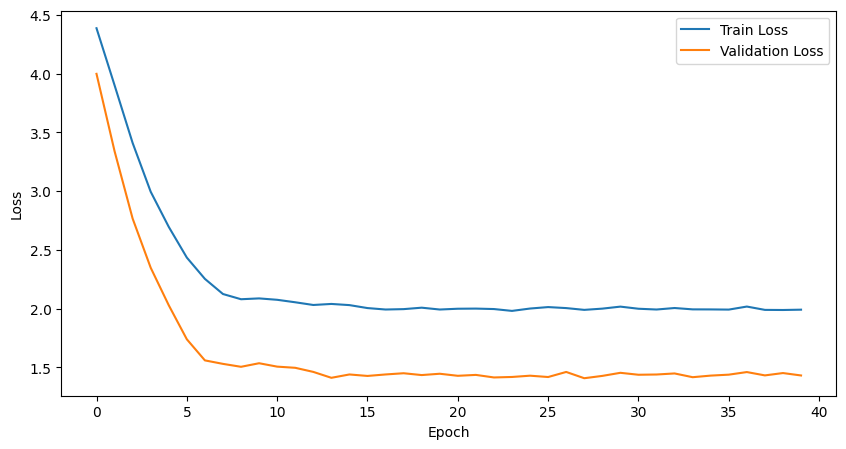

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig("outputs/training_curves.png")
plt.show()

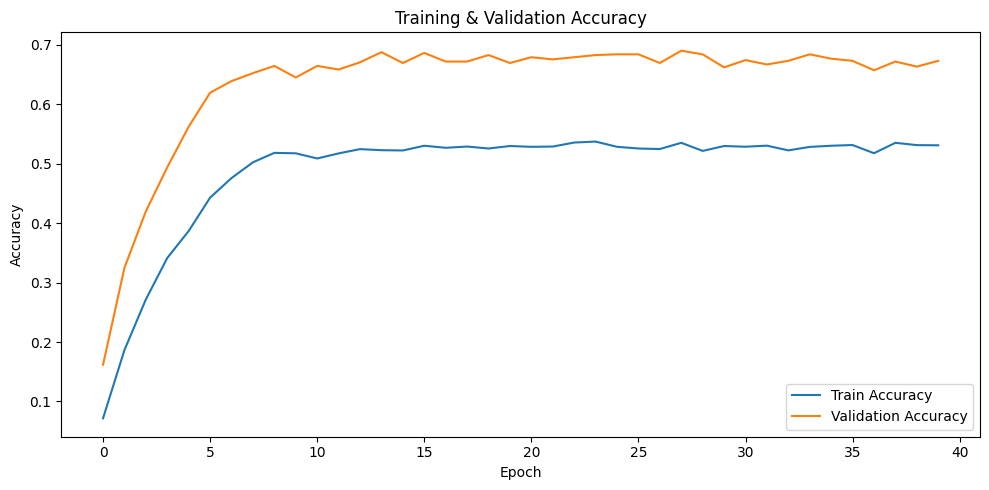

In [33]:
plt.figure(figsize=(10,5))
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig("outputs/training_accuracy.png")
plt.show()